In [145]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [146]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [175]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train', transform=None):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode
        self.transform = transform

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Convert to tensor and normalize
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        
        img = self.x[idx].view(1, 28, 28) 

        
        if self.transform:
            img = self.transform(img)
            
        
        return (img.view(-1), self.y[idx]) if self.mode == 'train' else img.view(-1)

In [176]:
train_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.Normalize((0.5,), (0.5,))
])

val_transforms = transforms.Compose([
    transforms.Normalize((0.5,), (0.5,))
])

In [177]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


---
<div style="text-align: center"><h1> Part4- Implementation</h1></div>


---
## Part A: The Pancake (Width Focus)
**Shallow but wide**: 1–2 hidden layers, 1024–2048 neurons per layer.  
**Hypothesis**: Does raw memorization power (large parameter count in one layer) solve the problem?

In [150]:

# ==========================================
# PART A: PANCAKE MODEL
# ==========================================
INPUT_SIZE = 784 
NUM_CLASSES = 15 # given the dataset has 15 classes. 

class PancakeMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(PancakeMLP, self).__init__()
        self.network = nn.Sequential(
            # hidden layer 1: wide
            nn.Linear(input_size, 1280),
            nn.BatchNorm1d(1280),
            nn.ReLU(),
            nn.Dropout(0.4),

            # hidden layer 2: wide
            nn.Linear(1280, 1280),
            nn.BatchNorm1d(1280),
            nn.ReLU(),
            nn.Dropout(0.3),

            # output
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = x.view(-1, 784)  # ensure flattened
        return self.network(x)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total

pancake_model = PancakeMLP(INPUT_SIZE, NUM_CLASSES)
pancake_params = count_parameters(pancake_model)
print(f"Pancake Model Architecture:")
print(pancake_model)
print(f"\nTotal Parameters: {pancake_params:,}")





Pancake Model Architecture:
PancakeMLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=1280, bias=True)
    (1): BatchNorm1d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=1280, out_features=1280, bias=True)
    (5): BatchNorm1d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=1280, out_features=15, bias=True)
  )
)

Total Parameters: 2,668,815


In [151]:
# ==========================================
# TRAINING UTILITY FUNCTIONS
# ==========================================

def train_epoch(model, loader, optimizer, criterion):
    """run one training epoch. returns avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y).sum().item()
        total   += X.size(0)

    return total_loss / total, 100.0 * correct / total


def eval_epoch(model, loader, criterion):
    """evaluate on validation set returns avg loss and accuracy."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            outputs = model(X)
            loss = criterion(outputs, y)
            total_loss += loss.item() * X.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(y).sum().item()
            total   += X.size(0)
    return total_loss / total, 100.0 * correct / total


def train_model(model, train_loader, val_loader,
                epochs=20, lr=1e-3, weight_decay=1e-4,
                model_name='model', patience=5):
    model = model.to(DEVICE)
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer  = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc  = 0.0
    best_state    = None
    no_improve    = 0
    start_time    = time.time()

    print(f"\n{'='*55}")
    print(f" Training: {model_name} | Epochs: {epochs} | LR: {lr}")
    print(f"{'='*55}")
    print(f"{'Epoch':>6} {'Tr Loss':>9} {'Tr Acc':>8} {'Va Loss':>9} {'Va Acc':>8} {'LR':>10}")
    print("-"*55)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = eval_epoch(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        cur_lr = optimizer.param_groups[0]['lr']
        print(f"{epoch:>6} {tr_loss:>9.4f} {tr_acc:>7.2f}% {va_loss:>9.4f} {va_acc:>7.2f}%  {cur_lr:.2e}")

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs).")
                break

    elapsed = time.time() - start_time
    print("-"*55)
    print(f" Best Val Acc: {best_val_acc:.2f}% | Time: {elapsed:.1f}s")
    print(f"{'='*55}\n")

    # Restore best weights
    model.load_state_dict(best_state)
    return model, history, best_val_acc


def plot_history(history, model_name='Model', save_path=None):
    """Plot training and validation accuracy/loss curves."""
    epochs_ran = len(history['train_loss'])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{model_name} – Training Curves', fontsize=13, fontweight='bold')

    ax1.plot(range(1, epochs_ran+1), history['train_loss'], label='Train Loss', color='steelblue')
    ax1.plot(range(1, epochs_ran+1), history['val_loss'],   label='Val Loss',   color='tomato')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(range(1, epochs_ran+1), history['train_acc'], label='Train Acc', color='steelblue')
    ax2.plot(range(1, epochs_ran+1), history['val_acc'],   label='Val Acc',   color='tomato')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

print("Training utility functions defined.")

Training utility functions defined.



 Training: Pancake (Wide, Shallow) | Epochs: 20 | LR: 0.001
 Epoch   Tr Loss   Tr Acc   Va Loss   Va Acc         LR
-------------------------------------------------------
     1    1.4253   65.34%    1.2638   71.05%  9.94e-04
     2    1.2452   72.63%    1.2095   73.24%  9.76e-04
     3    1.1766   75.90%    1.1793   74.98%  9.46e-04
     4    1.1215   78.30%    1.1425   76.67%  9.05e-04
     5    1.0776   80.31%    1.1300   77.34%  8.54e-04
     6    1.0376   82.06%    1.1268   77.38%  7.94e-04
     7    1.0027   83.54%    1.1155   78.35%  7.27e-04
     8    0.9687   85.17%    1.1023   78.74%  6.55e-04
     9    0.9397   86.54%    1.1002   78.88%  5.79e-04
    10    0.9087   87.77%    1.1010   79.21%  5.01e-04
    11    0.8793   89.42%    1.1021   79.22%  4.22e-04
    12    0.8524   90.65%    1.0999   79.63%  3.46e-04
    13    0.8292   91.98%    1.0972   79.86%  2.74e-04
    14    0.8106   92.75%    1.0974   79.62%  2.07e-04
    15    0.7927   93.76%    1.1012   79.61%  1.47e-04
  

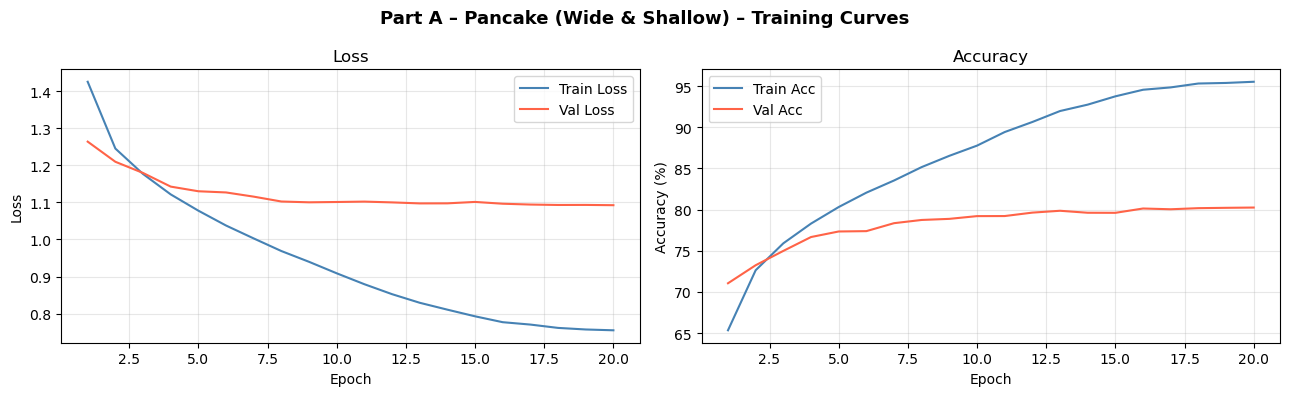

Pancake | Params: 2,668,815 | Best Val Acc: 80.25%


In [152]:
# ==========================================
# TRAIN PART A: PANCAKE
# ==========================================
PANCAKE_EPOCHS = 20

pancake_model, pancake_history, pancake_best_acc = train_model(
    PancakeMLP(INPUT_SIZE, NUM_CLASSES),
    train_loader, val_loader,
    epochs=PANCAKE_EPOCHS,
    lr=1e-3,
    weight_decay=1e-4,
    model_name='Pancake (Wide, Shallow)',
    patience=7
)

plot_history(pancake_history, 'Part A – Pancake (Wide & Shallow)', 'pancake_curves.png')
print(f"Pancake | Params: {pancake_params:,} | Best Val Acc: {pancake_best_acc:.2f}%")

---
## Part B: The Tower (Depth Focus)
**Deep but narrow**: 7 hidden layers, 256 neurons each.  
**Hypothesis**: Can hierarchical structure learn better features with fewer total parameters?  
Uses **BatchNorm** to mitigate vanishing gradients.

In [ ]:
# ==========================================
# PART B: TOWER MODEL
# ==========================================

class TowerMLP(nn.Module):

    def __init__(self, input_size=784, num_classes=15,
                 hidden_size=256, num_layers=7, dropout=0.3):
        super(TowerMLP, self).__init__()

        layers = []
        in_features = input_size

        for i in range(num_layers):
            layers += [
                nn.Linear(in_features, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.LeakyReLU(negative_slope=0.1),
                nn.Dropout(dropout)
            ]
            in_features = hidden_size

        layers.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layers)

        # creful initialization to help deep training
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.view(-1, 784)
        return self.network(x)


tower_model  = TowerMLP(INPUT_SIZE, NUM_CLASSES, hidden_size=256, num_layers=7)
tower_params = count_parameters(tower_model)
print(f"Tower Model Architecture:")
print(tower_model)
print(f"\nTotal Parameters: {tower_params:,}")
print(f"Parameter limit OK: {tower_params <= 3_000_000}")

Tower Model Architecture:
TowerMLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.1)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=256, bias=True)
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): LeakyReLU(negative_slope=0.1)
    (15): Dropout(p=0.3, inplace=False)
    (16): Lin


 Training: Tower (Deep, Narrow) | Epochs: 25 | LR: 0.0005
 Epoch   Tr Loss   Tr Acc   Va Loss   Va Acc         LR
-------------------------------------------------------
     1    2.2887   30.25%    1.6347   53.03%  4.98e-04
     2    1.7300   50.90%    1.4512   62.59%  4.92e-04
     3    1.5847   57.58%    1.3958   64.51%  4.82e-04
     4    1.5080   60.93%    1.3564   66.55%  4.69e-04
     5    1.4601   62.99%    1.3278   67.63%  4.52e-04
     6    1.4194   64.73%    1.3057   68.73%  4.32e-04
     7    1.3918   66.01%    1.2820   69.85%  4.10e-04
     8    1.3637   67.28%    1.2717   70.16%  3.84e-04
     9    1.3374   68.20%    1.2586   70.88%  3.57e-04
    10    1.3215   69.08%    1.2490   71.26%  3.28e-04
    11    1.3013   69.59%    1.2421   71.45%  2.97e-04
    12    1.2912   69.98%    1.2306   71.88%  2.66e-04
    13    1.2750   70.67%    1.2287   72.03%  2.35e-04
    14    1.2646   71.09%    1.2270   72.27%  2.04e-04
    15    1.2556   71.52%    1.2127   72.83%  1.73e-04
    

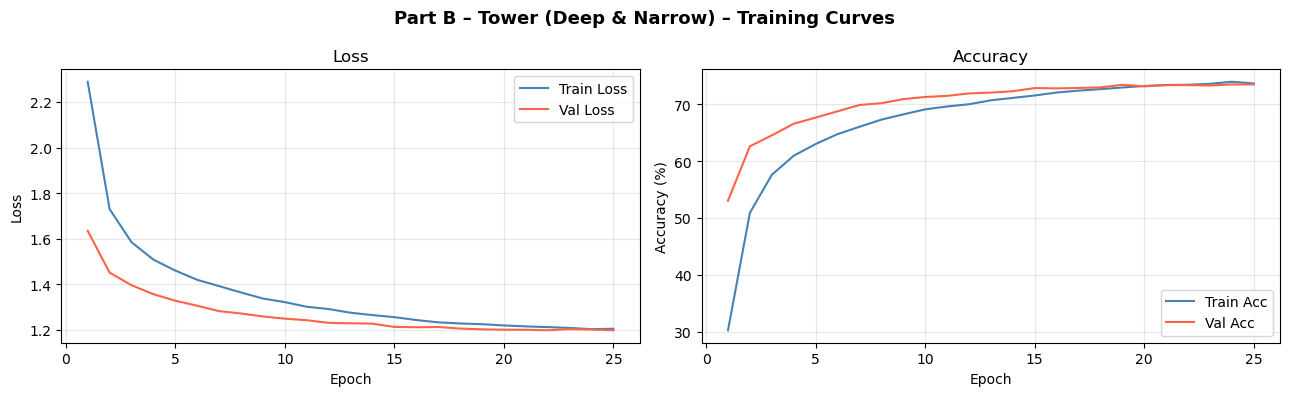

Tower   | Params: 603,151 | Best Val Acc: 73.47%


In [154]:
# ==========================================
# TRAIN PART B: TOWER
# ==========================================
TOWER_EPOCHS = 25

tower_model, tower_history, tower_best_acc = train_model(
    TowerMLP(INPUT_SIZE, NUM_CLASSES, hidden_size=256, num_layers=7),
    train_loader, val_loader,
    epochs=TOWER_EPOCHS,
    lr=5e-4,          # lower LR helps deep networks converge more stably
    weight_decay=1e-4,
    model_name='Tower (Deep, Narrow)',
    patience=8
)

plot_history(tower_history, 'Part B – Tower (Deep & Narrow)', 'tower_curves.png')
print(f"Tower   | Params: {tower_params:,} | Best Val Acc: {tower_best_acc:.2f}%")

---
## Part C: The Champion
Balanced architecture that combines the strengths of width AND depth.  
Uses **GELU** activation (smoother than ReLU), **label smoothing**, and **cosine LR scheduling**.



In [ ]:
# ==========================================
# PART C: CHAMPION MODEL
# ==========================================
class ChampionMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(ChampionMLP, self).__init__()

        def block(in_f, out_f, drop=0.4):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f), 
                nn.GELU(),
                nn.Dropout(drop)
            )

      
        self.network = nn.Sequential(
            block(input_size, 800, drop=0.4),
            block(800,        320, drop=0.35), 
            block(320,        128, drop=0.25), 
            nn.Linear(128, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.network(x.view(-1, 784))

champion_model  = ChampionMLP(INPUT_SIZE, NUM_CLASSES)
champion_params = count_parameters(champion_model)
print(f"Champion Model Architecture:")
print(champion_model)
print(f"\nTotal Parameters: {champion_params:,}")
print(f"Parameter limit OK: {champion_params <= 3_000_000}")

Champion Model Architecture:
ChampionMLP(
  (network): Sequential(
    (0): Sequential(
      (0): Linear(in_features=784, out_features=800, bias=True)
      (1): BatchNorm1d(800, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.45, inplace=False)
    )
    (1): Sequential(
      (0): Linear(in_features=800, out_features=320, bias=True)
      (1): BatchNorm1d(320, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.35, inplace=False)
    )
    (2): Sequential(
      (0): Linear(in_features=320, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.25, inplace=False)
    )
    (3): Linear(in_features=128, out_features=15, bias=True)
  )
)

Total Parameters: 929,839
Parameter limit OK: True



 Training: Champion (Funnel MLP) | Epochs: 20 | LR: 0.0012
 Epoch   Tr Loss   Tr Acc   Va Loss   Va Acc         LR
-------------------------------------------------------
     1    1.5939   58.23%    1.2916   69.95%  1.19e-03
     2    1.3474   68.35%    1.2276   72.78%  1.17e-03
     3    1.2726   71.59%    1.1938   73.69%  1.13e-03
     4    1.2175   73.79%    1.1627   75.20%  1.09e-03
     5    1.1746   75.69%    1.1350   76.82%  1.02e-03
     6    1.1392   77.36%    1.1207   77.40%  9.53e-04
     7    1.1039   78.76%    1.1104   77.92%  8.73e-04
     8    1.0761   80.11%    1.1040   78.38%  7.86e-04
     9    1.0476   81.23%    1.0947   79.03%  6.94e-04
    10    1.0178   82.57%    1.0918   79.22%  6.01e-04
    11    0.9991   83.56%    1.0872   79.67%  5.07e-04
    12    0.9784   84.59%    1.0871   79.94%  4.15e-04
    13    0.9576   85.32%    1.0894   79.73%  3.28e-04
    14    0.9400   86.18%    1.0865   80.08%  2.48e-04
    15    0.9249   87.06%    1.0852   80.28%  1.77e-04
   

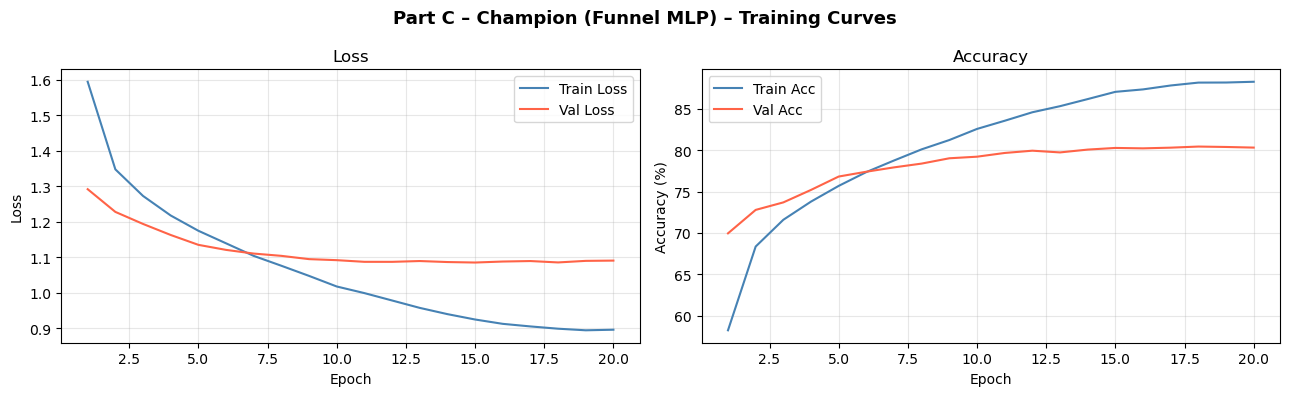

Champion weights saved to 'champion_model_weights.pth'
Champion | Params: 929,839 | Best Val Acc: 80.44%


In [201]:
# ==========================================
# TRAIN PART C: CHAMPION
# ==========================================
CHAMPION_EPOCHS = 20

champion_model, champion_history, champion_best_acc = train_model(
    ChampionMLP(INPUT_SIZE, NUM_CLASSES),
    train_loader, val_loader,
    epochs=CHAMPION_EPOCHS,
    lr=1.2e-3,
    weight_decay=2e-4,
    model_name='Champion (Funnel MLP)',
    patience=10
)

plot_history(champion_history, 'Part C – Champion (Funnel MLP)', 'champion_curves.png')

# sve best champion weights
torch.save(champion_model.state_dict(), 'champion_model_weights.pth')
print(f"Champion weights saved to 'champion_model_weights.pth'")
print(f"Champion | Params: {champion_params:,} | Best Val Acc: {champion_best_acc:.2f}%")


 MODEL COMPARISON SUMMARY
Model                    Parameters  Epochs Run  Best Val Acc
------------------------------------------------------------------------
Part A: Pancake           2,668,815          20        80.25%
Part B: Tower               603,151          25        73.47%
Part C: Champion            929,839          20        80.44%


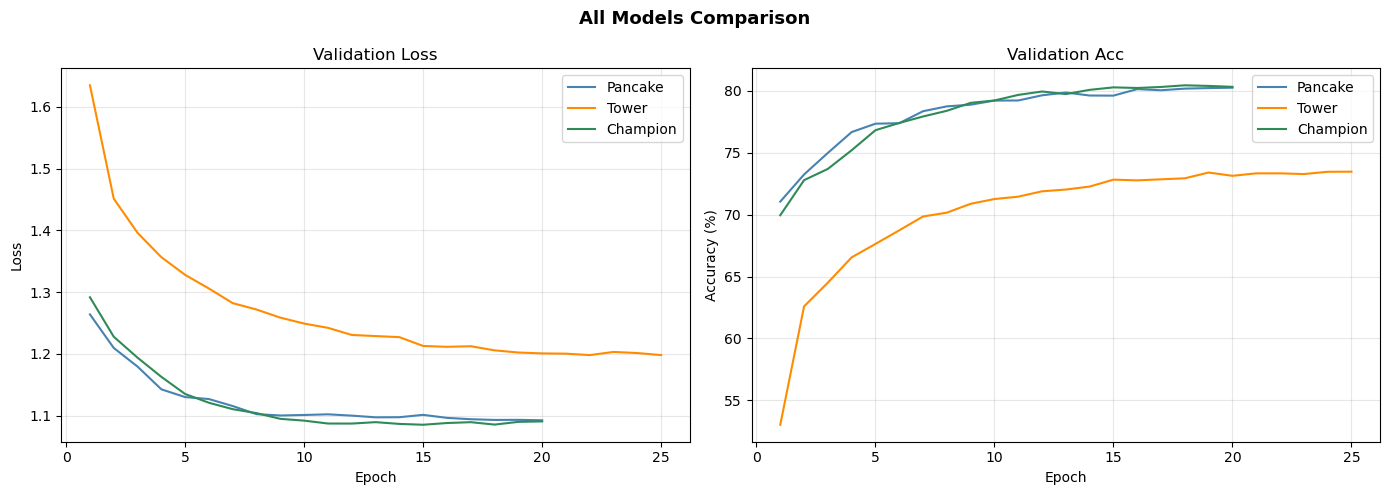

In [202]:
# ==========================================
# MODEL COMPARISON TABLE
# ==========================================

print("\n" + "="*72)
print(" MODEL COMPARISON SUMMARY")
print("="*72)
print(f"{'Model':<22} {'Parameters':>12} {'Epochs Run':>11} {'Best Val Acc':>13}")
print("-"*72)
print(f"{'Part A: Pancake':<22} {pancake_params:>12,} {len(pancake_history['val_acc']):>11} {pancake_best_acc:>12.2f}%")
print(f"{'Part B: Tower':<22} {tower_params:>12,} {len(tower_history['val_acc']):>11} {tower_best_acc:>12.2f}%")
print(f"{'Part C: Champion':<22} {champion_params:>12,} {len(champion_history['val_acc']):>11} {champion_best_acc:>12.2f}%")
print("="*72)

# Overlay comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('All Models Comparison', fontsize=13, fontweight='bold')

colors = {'Pancake': 'steelblue', 'Tower': 'darkorange', 'Champion': 'seagreen'}
histories = {
    'Pancake':  pancake_history,
    'Tower':    tower_history,
    'Champion': champion_history
}

for name, h in histories.items():
    ep = range(1, len(h['val_loss'])+1)
    ax1.plot(ep, h['val_loss'], label=name, color=colors[name])
    ax2.plot(ep, h['val_acc'],  label=name, color=colors[name])

ax1.set_title('Validation Loss');  ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss');        ax1.legend(); ax1.grid(alpha=0.3)
ax2.set_title('Validation Acc');   ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part D: Theoretical Analysis
### D1. Width vs. Depth Analysis
### D2. Confusion Matrix & Confusion Pair Analysis

Computing confusion matrix on validation set...


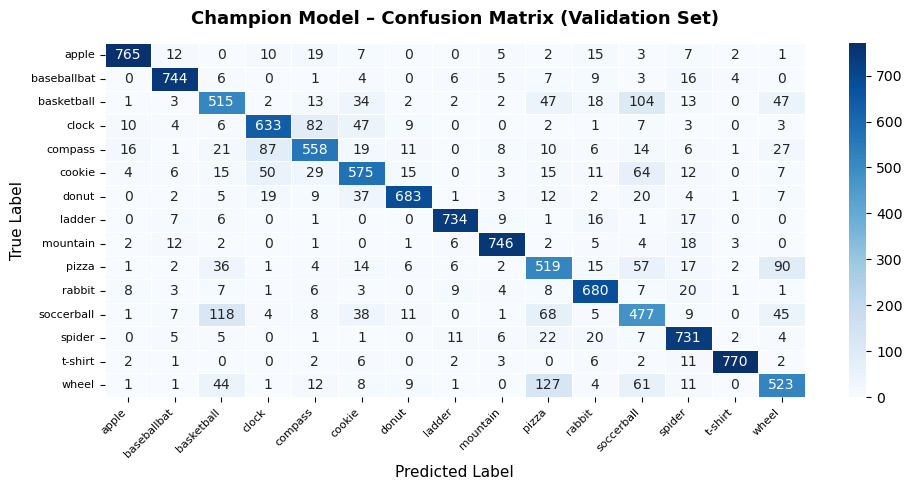


Classification Report:
              precision    recall  f1-score   support

       apple       0.94      0.90      0.92       848
 baseballbat       0.92      0.92      0.92       805
  basketball       0.66      0.64      0.65       803
       clock       0.78      0.78      0.78       807
     compass       0.75      0.71      0.73       785
      cookie       0.73      0.71      0.72       806
       donut       0.91      0.85      0.88       805
      ladder       0.94      0.93      0.94       792
    mountain       0.94      0.93      0.93       802
       pizza       0.62      0.67      0.64       772
      rabbit       0.84      0.90      0.87       758
  soccerball       0.57      0.60      0.59       792
      spider       0.82      0.90      0.85       815
     t-shirt       0.98      0.95      0.97       807
       wheel       0.69      0.65      0.67       803

    accuracy                           0.80     12000
   macro avg       0.81      0.80      0.80     12000
we

In [203]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# ==========================================
# PART D: CONFUSION MATRIX (Champion Model)
# ==========================================

def get_all_predictions_and_labels(model, loader):
    """Run inference and collect all predictions + true labels."""
    model.eval()
    model.to(DEVICE)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            outputs = model(X)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y.numpy())
    return np.array(all_preds), np.array(all_labels)


print("Computing confusion matrix on validation set...")
val_preds, val_labels = get_all_predictions_and_labels(champion_model, val_loader)

cm = confusion_matrix(val_labels, val_preds)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES,
    ax=ax, linewidths=0.4
)
ax.set_title('Champion Model – Confusion Matrix (Validation Set)', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(val_labels, val_preds, target_names=CLASSES))

In [204]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(champion_model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [205]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(champion_model)


Model Statistics:
  Total Parameters: 929,839
  ✅ Parameter count is within limits.
